In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('Restaurant_Reviews.tsv', delimiter='\t', quoting=3)

df.head()


,Review,Liked
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1


In [3]:
df.shape

(1000, 2)

In [4]:
df.head()

,Review,Liked
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1


In [5]:
import nltk
import re

nltk.download('stopwords')

from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Vennila\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


In [7]:

corpus = []

for i in range(0, 1000):

    
    review = re.sub(
        pattern='[^a-zA-Z]',
        repl=' ',
        string=df['Review'][i]
    )

  
    review = review.lower()

   
    review_words = review.split()

  
    review_words = [
        word for word in review_words
        if not word in set(stopwords.words('english'))
    ]

    ps = PorterStemmer()
    review = [ps.stem(word) for word in review_words]

   
    review = ' '.join(review)

  
    corpus.append(review)

corpus[0:10]

['wow love place',
 'crust good',
 'tasti textur nasti',
 'stop late may bank holiday rick steve recommend love',
 'select menu great price',
 'get angri want damn pho',
 'honeslti tast fresh',
 'potato like rubber could tell made ahead time kept warmer',
 'fri great',
 'great touch']

In [9]:

from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(max_features=1500)

X = cv.fit_transform(corpus).toarray()

y = df.iloc[:, 1].values

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=0
)

from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=35)

model.fit(X_train, y_train)

model.score(X_test, y_test)

0.715

In [11]:

y_pred = model.predict(X_test)

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score

score1 = accuracy_score(y_test, y_pred)
score2 = precision_score(y_test, y_pred)
score3 = recall_score(y_test, y_pred)

print("---- Scores ----")
print("Accuracy score is: {}%".format(round(score1 * 100, 2)))
print("Precision score is: {}".format(round(score2, 2)))
print("Recall score is: {}".format(round(score3, 2)))

---- Scores ----
Accuracy score is: 71.5%
Precision score is: 0.82
Recall score is: 0.57


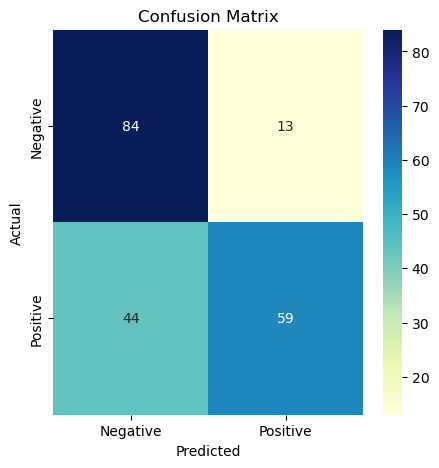

In [12]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,5))

sns.heatmap(
    cm,
    annot=True,
    cmap="YlGnBu",
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()